In [33]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [3]:
import seaborn as sns
iris = sns.load_dataset("iris")

data = torch.tensor( iris[iris.columns[0:4]].values ).float()

labels = torch.zeros( len(data), dtype=torch.long )
labels[iris.species=="versicolor"] = 1
labels[iris.species=="virginica"] = 2

In [4]:
propTraining = .8
nTraining = int(len(labels)*propTraining)

traintestBool = np.zeros(len(labels), dtype=bool)



# traintestBool[range(nTraining)] = True
items2use4train = np.random.choice(range(len(labels)), nTraining, replace=False)
traintestBool[items2use4train] = True

traintestBool

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False,  True, False,
        True,  True, False,  True,  True,  True, False,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True,

In [36]:
print("Average of full data: ")
print( torch.mean(labels.float()), end="\n\n")

print("Average of training data: ")
print( torch.mean(labels[traintestBool].float()), end="\n\n")

print("Average of test data: ")
print( torch.mean(labels[~traintestBool].float()) )

Average of full data: 
tensor(1.)

Average of training data: 
tensor(0.9667)

Average of test data: 
tensor(1.1333)


In [37]:
def createANewModel():
    ANNiris = nn.Sequential(
        nn.Linear(4, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 3),
    )
    
    lossfun = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.SGD(ANNiris.parameters(), lr=0.01)

    return ANNiris, lossfun, optimizer

In [38]:
data.shape

torch.Size([150, 4])

In [39]:
data[traintestBool, :].shape

torch.Size([120, 4])

In [40]:
data[~traintestBool, :].shape

torch.Size([30, 4])

In [41]:
def trainTheModel(trainProp):

    numepochs = 500
    
    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    X_train, X_test, y_train, y_test = train_test_split(data, labels, train_size=trainProp)
    
    for epochi in range(numepochs):

        yHat = ANNiris(X_train)
        loss = lossfun(yHat, y_train)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        trainAcc.append(100*torch.mean((torch.argmax(yHat, axis=1) == y_train).float()).item())
        
        predlabels = torch.argmax( ANNiris(X_test), axis=1 )
        testAcc.append(100*torch.mean((predlabels == y_test).float()).item() )

    return trainAcc, testAcc

In [42]:
Anniris, lossfun, optimizer = createANewModel()

trainAcc, testAcc = trainTheModel(.8)

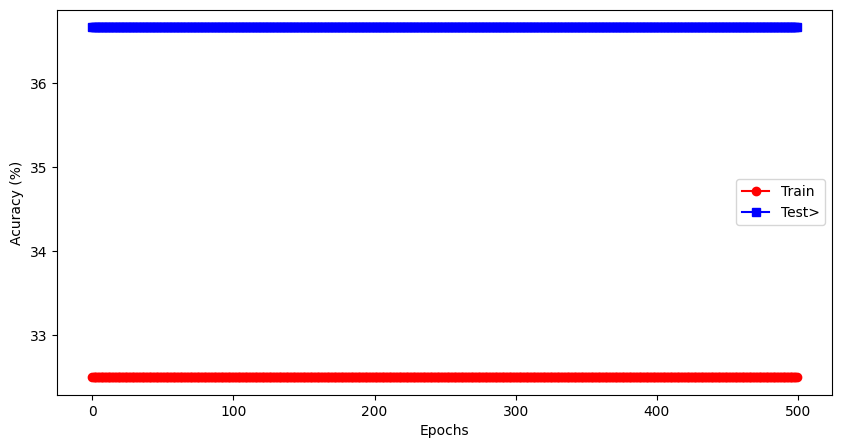

In [43]:
fig = plt.figure(figsize=(10,5))

plt.plot(trainAcc, 'ro-')
plt.plot(testAcc, 'bs-')
plt.xlabel('Epochs')
plt.ylabel('Acuracy (%)')
plt.legend(['Train', 'Test>'])
plt.show()